## Import 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline

from diasense.config import (
    CLINICAL_FEATURES,
    CLUSTERING_FEATURES,
    CLINICAL_THRESHOLDS,
    KMEANS_K,
    K_RANGE,
    FIGURES_DIR,
    MODELS_DIR,
    PROCESSED_DATA_DIR,
)
from diasense.data import load_raw_data, validate_columns
from diasense.preprocessing import (
    ColumnSelector,
    build_preprocessing_pipeline,
    inverse_scale,
    save_artifact,
)
from diasense.clustering import evaluate_k, fit_kmeans
from diasense.risk import (
    add_risk_category,
    learn_risk_mapping,
    save_risk_mapping,
)

sns.set_theme(style="whitegrid")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

#  Load

In [2]:
df_raw = load_raw_data()
validate_columns(df_raw)

X_raw = df_raw[CLINICAL_FEATURES].copy()

# Fit once on the 8 clinical measurements
preprocessing = build_preprocessing_pipeline()
X_prepared = preprocessing.fit_transform(X_raw)

# Select the 3 features used for K-Means
selector = ColumnSelector(CLUSTERING_FEATURES)
X_cluster = selector.fit_transform(X_prepared)

assert X_cluster.shape == (len(df_raw), 3)
assert not X_cluster.isna().any().any()

print("Raw data:", X_raw.shape)
print("Clustering input:", X_cluster.shape)
print("Selected features:", list(X_cluster.columns))

display(X_cluster.head())

Raw data: (768, 8)
Clustering input: (768, 3)
Selected features: ['Glucose', 'BMI', 'DiabetesPedigreeFunction']


,Glucose,BMI,DiabetesPedigreeFunction
0,0.862287,0.165097,0.468492
1,-1.202229,-0.846404,-0.365061
2,2.009241,-1.323254,0.604397
3,-1.071148,-0.629654,-0.920763
4,0.501816,1.537847,3.001955


## Elbow and silhouette plots

,k,inertia,silhouette
0,2,1508.2220,0.3070
1,3,1203.4743,0.2872
2,4,974.5469,0.2700
3,5,837.4130,0.2697
4,6,734.5077,0.2815
5,7,662.6291,0.2563
6,8,609.0068,0.2591
7,9,562.9784,0.2548
8,10,518.2780,0.2585


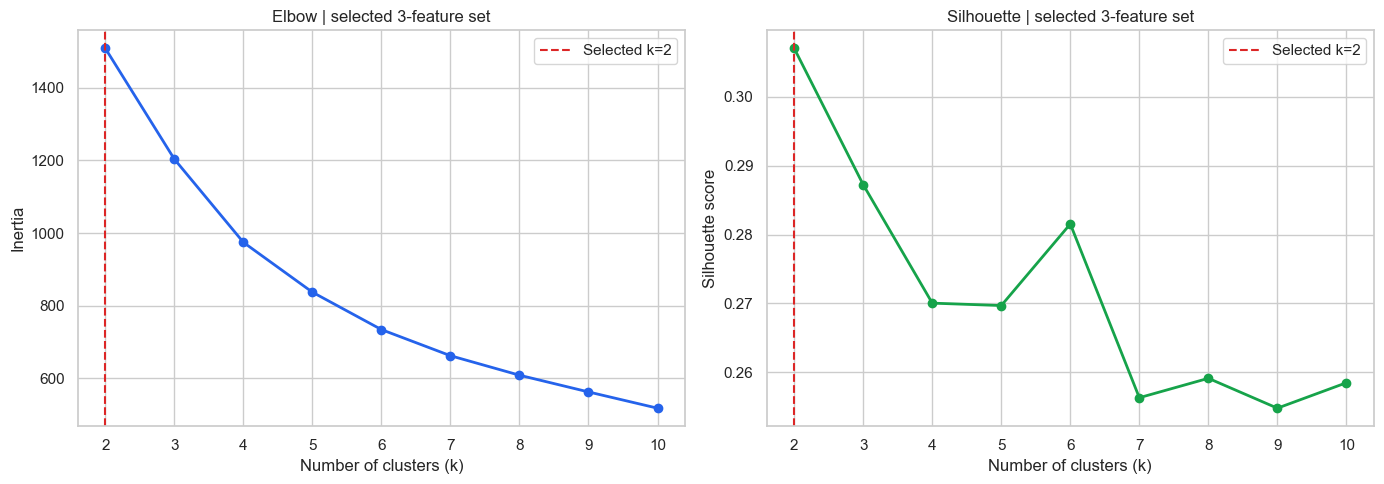

Best silhouette: k=2, score=0.307


In [4]:
k_results = evaluate_k(X_cluster, k_values=K_RANGE)

display(k_results.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    k_results["k"],
    k_results["inertia"],
    marker="o",
    linewidth=2,
    color="#2563eb",
)
axes[0].axvline(
    KMEANS_K,
    color="#dc2626",
    linestyle="--",
    label=f"Selected k={KMEANS_K}",
)
axes[0].set_title("Elbow | selected 3-feature set")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(k_results["k"])
axes[0].legend()

axes[1].plot(
    k_results["k"],
    k_results["silhouette"],
    marker="o",
    linewidth=2,
    color="#16a34a",
)
axes[1].axvline(
    KMEANS_K,
    color="#dc2626",
    linestyle="--",
    label=f"Selected k={KMEANS_K}",
)
axes[1].set_title("Silhouette | selected 3-feature set")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_xticks(k_results["k"])
axes[1].legend()

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "clustering_elbow_silhouette.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

best_row = k_results.loc[k_results["silhouette"].idxmax()]
print(
    f"Best silhouette: k={int(best_row['k'])}, "
    f"score={best_row['silhouette']:.3f}"
)

## Train K-Means

In [5]:
kmeans = fit_kmeans(X_cluster, k=KMEANS_K)

cluster_labels = kmeans.labels_

print("Inertia:", round(kmeans.inertia_, 2))
print("Silhouette:", round(silhouette_score(X_cluster, cluster_labels), 3))
print("Cluster counts:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Inertia: 1508.22
Silhouette: 0.307
Cluster counts:
0    269
1    499
Name: count, dtype: int64


## Recover Treated values in clinical

In [7]:
X_clinical = inverse_scale(preprocessing,X_prepared)

df_profiles = X_clinical.copy()
df_profiles["Cluster"] = cluster_labels

print("First treated patient records")
display(df_profiles.head())

First treated patient records


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cluster
0,6.0,148.0,72.0,35.0,264.8,33.6,0.627000,50.0,0
1,1.0,85.0,66.0,29.0,65.2,26.6,0.351000,31.0,1
2,8.0,183.0,64.0,30.6,198.2,23.3,0.672000,32.0,0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167000,21.0,1
4,0.0,137.0,40.0,35.0,168.0,43.1,1.465862,33.0,0


## Cluster counts & clinical profiles

In [15]:
cluster_counts = df_profiles["Cluster"].value_counts().sort_index()

cluster_profiles = (
    df_profiles.groupby("Cluster")[CLINICAL_FEATURES].mean()
)

display(cluster_profiles.round(2))
display(cluster_counts.rename("number_of_patients").to_frame())
# display(cluster_profiles.describe())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Cluster,,,,,,,,
0,4.36,151.30,76.53,33.62,213.3,36.87,0.60,36.60
1,3.56,105.58,70.15,26.43,118.0,29.98,0.39,31.39


,number_of_patients
Cluster,
0,269
1,499


## Visualize cluster sizes & the three selected features

The clustering was performed using three features Glucose, BMI, and DiabetesPedigreeFunction but this visualization shows only Glucose and BMI. Therefore, some points may overlap because the third feature, which also influenced the clustering, is not visible in the 2D plot.

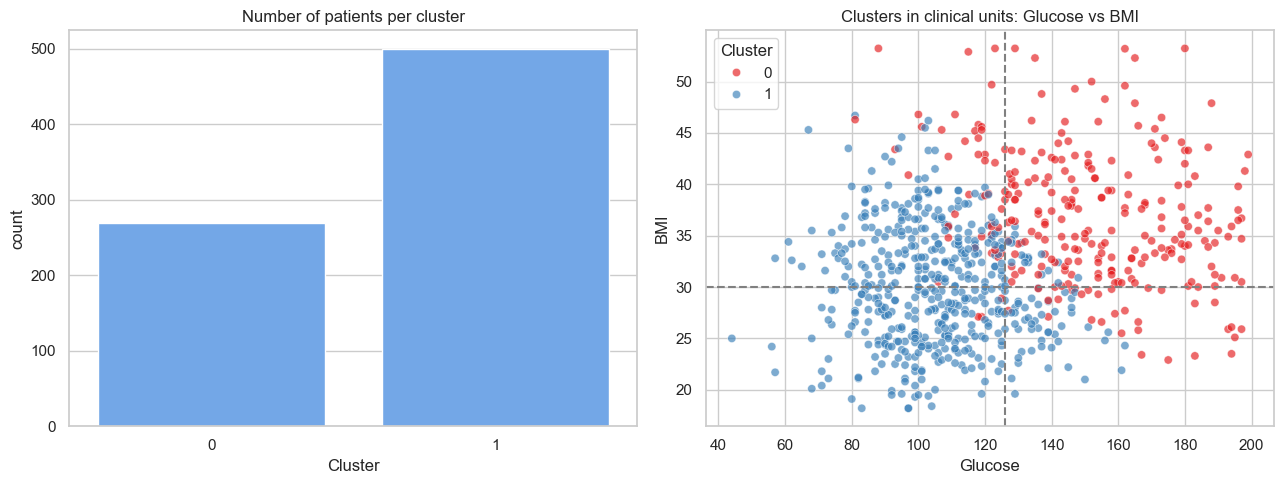

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(
    data=df_profiles,
    x="Cluster",
    ax=axes[0],
    color="#60a5fa",
)
axes[0].set_title("Number of patients per cluster")


# Second
sns.scatterplot(
    data=df_profiles,
    x="Glucose",
    y="BMI",
    hue="Cluster",
    palette="Set1",
    alpha=0.65,
    ax=axes[1],
)
axes[1].axvline(
    CLINICAL_THRESHOLDS["Glucose"],
    color="gray",
    linestyle="--",
)
axes[1].axhline(
    CLINICAL_THRESHOLDS["BMI"],
    color="gray",
    linestyle="--",
)
axes[1].set_title("Clusters in clinical units: Glucose vs BMI")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "clustering_distribution.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Inspect the three risk thresholds

In [18]:
threshold_report = cluster_profiles[
    list(CLINICAL_THRESHOLDS)
].round(3).copy()

for feature, threshold in CLINICAL_THRESHOLDS.items():
    threshold_report[f"{feature}_above_threshold"] = (
        cluster_profiles[feature] > threshold
    )

display(threshold_report)

print("Required cluster mean thresholds:")
for feature, threshold in CLINICAL_THRESHOLDS.items():
    print(f"  {feature} > {threshold}")

,Glucose,BMI,DiabetesPedigreeFunction,Glucose_above_threshold,BMI_above_threshold,DiabetesPedigreeFunction_above_threshold
Cluster,,,,,,
0,151.303,36.872,0.604,True,True,True
1,105.579,29.981,0.391,False,False,False


Required cluster mean thresholds:
  Glucose > 126.0
  BMI > 30.0
  DiabetesPedigreeFunction > 0.5
